In [1]:
from pathlib import Path
import os

os.chdir("..")

In [2]:
path = Path("data/raw/aclImdb")

# Explore the dataset folder

In [3]:
def tree(path, level=0, indent=4, max_files=3):
    if level == 0:
        print(f"{path}/")
        level += 1
    sub_paths = sorted(path.iterdir())
    sub_dirs = [sub_path for sub_path in sub_paths if sub_path.is_dir()]
    filepaths = [sub_path for sub_path in sub_paths if not sub_path in sub_dirs]
    indent_str = " " * indent * level
    for sub_dir in sub_dirs:
        print(f"{indent_str}{sub_dir.name}/")
        tree(sub_dir,  level + 1, indent)
    for filepath in filepaths[:max_files]:
        print(f"{indent_str}{filepath.name}")
    if len(filepaths) > max_files:
        print(f"{indent_str}...")

In [4]:
tree(path)

data\raw\aclImdb/
    test/
        neg/
            0_2.txt
            10000_4.txt
            10001_1.txt
            ...
        pos/
            0_10.txt
            10000_7.txt
            10001_9.txt
            ...
        labeledBow.feat
        urls_neg.txt
        urls_pos.txt
    train/
        neg/
            0_3.txt
            10000_4.txt
            10001_4.txt
            ...
        pos/
            0_9.txt
            10000_8.txt
            10001_10.txt
            ...
        unsup/
            0_0.txt
            10000_0.txt
            10001_0.txt
            ...
        labeledBow.feat
        unsupBow.feat
        urls_neg.txt
        ...
    imdb.vocab
    imdbEr.txt
    README


# Load Data

In [5]:
def review_paths(dirpath):
    return [str(path) for path in dirpath.glob("*.txt")]

train_pos = review_paths(path / "train" / "pos")
train_neg = review_paths(path / "train" / "neg")
test_valid_pos = review_paths(path / "test" / "pos")
test_valid_neg = review_paths(path / "test" / "neg")

len(train_pos), len(train_neg), len(test_valid_pos), len(test_valid_neg)

(12500, 12500, 12500, 12500)

In [6]:
import pandas as pd

def load_review(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def create_df_reviews(pos_review_path, neg_review_path):
    pos_reviews = [load_review(path) for path in pos_review_path]
    neg_reviews =  [load_review(path) for path in neg_review_path]
    reviews = pos_reviews + neg_reviews
    labels = ['positive' for i in range(len(pos_reviews))] + ['negative' for i in range(len(neg_reviews))] 
    df = pd.DataFrame({'review': reviews, 'label': labels})
    return df

train_df = create_df_reviews(train_pos, train_neg)
test_val_df = create_df_reviews(test_valid_pos, test_valid_neg)

# EDA

## Data Quality Checks

In [7]:
def check_data_quality(df):
    print("Shape of dataset:", df.shape)
    print("Number of missing reviews:", (df['review'].str.strip() == "").sum())
    print("Number of duplicate reviews:", df['review'].duplicated().sum())    

In [8]:
def show_duplicates(df):
    duplicates = df[df["review"].duplicated(keep=False)]        # gets the duplicated reviews from df
    return duplicates.sort_values("review")

In [9]:
def show_dup_dif_lab(df):
    conflicting = df.groupby("review")["label"].nunique()
    print(len(conflicting[conflicting > 1]))
    conflicting[conflicting > 1]

### Train Set Data Quality Checks

In [10]:
print("Train set:")
check_data_quality(train_df)

print("\nDuplicates in train set:")
show_duplicates(train_df)


Train set:
Shape of dataset: (25000, 2)
Number of missing reviews: 0
Number of duplicate reviews: 96

Duplicates in train set:


,review,label
24842,'Dead Letter Office' is a low-budget film abou...,negative
18447,'Dead Letter Office' is a low-budget film abou...,negative
8131,".......Playing Kaddiddlehopper, Col San Fernan...",positive
11742,".......Playing Kaddiddlehopper, Col San Fernan...",positive
21983,"<br /><br />Back in his youth, the old man had...",negative
...,...,...
21463,"in this movie, joe pesci slams dunks a basketb...",negative
11006,it's amazing that so many people that i know h...,positive
11003,it's amazing that so many people that i know h...,positive
19538,this movie begins with an ordinary funeral... ...,negative


In [11]:
show_dup_dif_lab(train_df)

0


96 duplicate reviews were found in train set, but none have conflicting labels

In [12]:
# Drop duplicates
train_df = train_df.drop_duplicates(subset="review")
train_df.shape

(24904, 2)

### Test and Val Set Data Quality Checks

In [13]:
print("Test_val set:")
check_data_quality(test_val_df)

print("\nDuplicates in test_val set:")
show_duplicates(test_val_df)

Test_val set:
Shape of dataset: (25000, 2)
Number of missing reviews: 0
Number of duplicate reviews: 199

Duplicates in test_val set:


,review,label
13584,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
16314,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
20653,"""Three"" is a seriously dumb shipwreck movie. M...",negative
18476,"""Three"" is a seriously dumb shipwreck movie. M...",negative
17360,(Spoilers)<br /><br />Oh sure it's based on Mo...,negative
...,...,...
20649,this is the worst film I've seen in a long lon...,negative
17637,this movie sucks. did anyone notice that the e...,negative
16072,this movie sucks. did anyone notice that the e...,negative
4689,"when I first heard about this movie, I noticed...",positive


In [14]:
show_dup_dif_lab(test_val_df)

0


199 duplicate reviews were found in train set, but none have conflicting labels

In [15]:
# Drop duplicates
test_val_df = test_val_df.drop_duplicates(subset="review")
test_val_df.shape

(24801, 2)

### Train, Test, and Val Set Duplicate Check

In [16]:
train_test_val_df = pd.concat([train_df, test_val_df])
num_duplicates = train_test_val_df["review"].duplicated().sum()
if num_duplicates > 0:
    print("Number of reviews appearing in both train and test/validation:", num_duplicates)
    print("\nConflicting labels in duplicate reviews:")
    show_dup_dif_lab(train_test_val_df)
else:
    print("No overlap found in both train and test/validation")

Number of reviews appearing in both train and test/validation: 123

Conflicting labels in duplicate reviews:
0


## Sentiment Distribution

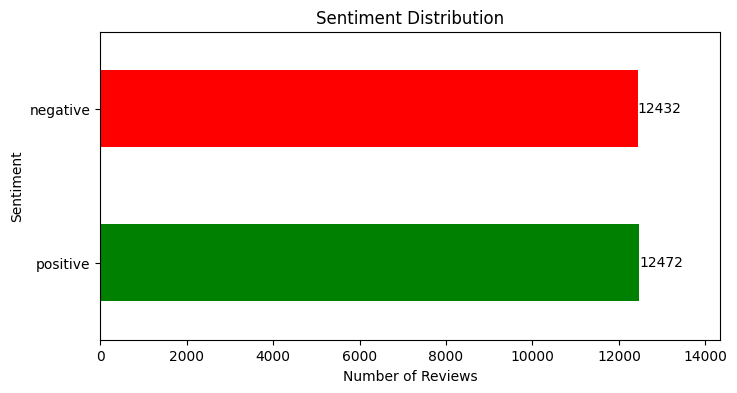

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sentiment_counts = train_df['label'].value_counts()
ax = sentiment_counts.plot(kind="barh", color=["green", "red"])

ax.bar_label(ax.containers[0])
ax.set_xlim(0, sentiment_counts.max() * 1.15)
plt.title("Sentiment Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Sentiment")
plt.show()


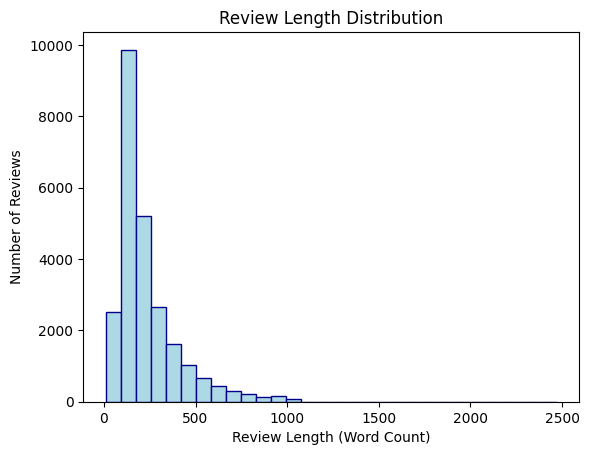

In [18]:
import matplotlib.pyplot as plt

train_df['review_length'] = train_df['review'].str.split().str.len()

train_df['review_length'].plot(kind="hist", bins=30, color="lightblue", edgecolor="darkblue")

plt.title("Review Length Distribution")
plt.xlabel("Review Length (Word Count)")
plt.ylabel("Number of Reviews")
plt.show()

## Most Frequently Occuring Words

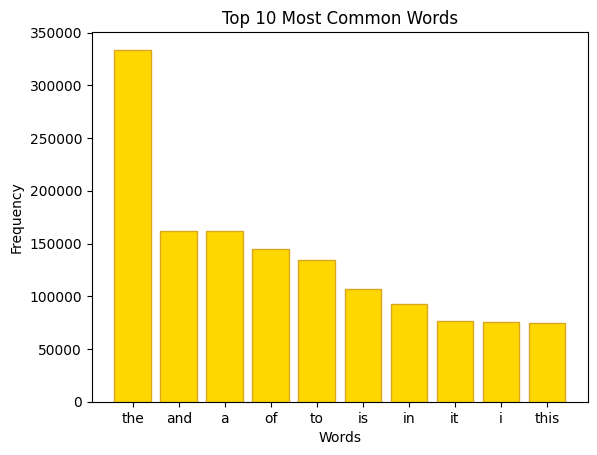

In [35]:
import string
from collections import Counter
import matplotlib.pyplot as plt

reviews = train_df["review"]

words = [
    word
    for review in reviews
    for word in review.lower().translate(
        str.maketrans("", "", string.punctuation)
    ).split()
]

word_counts = Counter(words)
top_10_words = word_counts.most_common(10)
words_list = [item[0] for item in top_10_words]
counts_list = [item[1] for item in top_10_words]

plt.bar(words_list, counts_list, color="gold", edgecolor="goldenrod")

plt.title("Top 10 Most Common Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

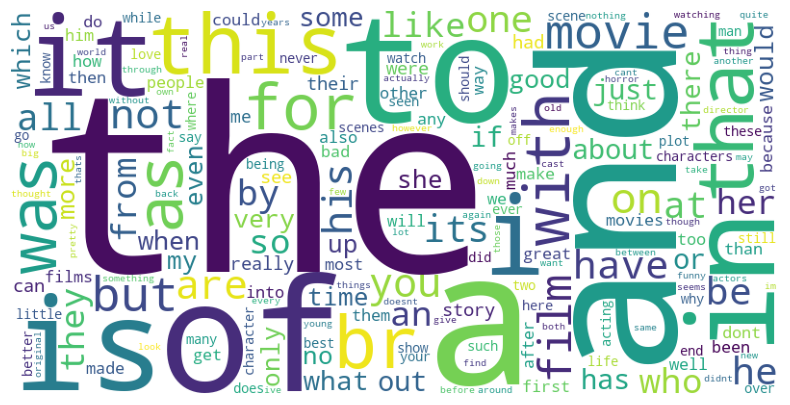

In [36]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(word_counts):
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(word_counts)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

create_wordcloud(word_counts)


## Most Frequent Words by Sentiment

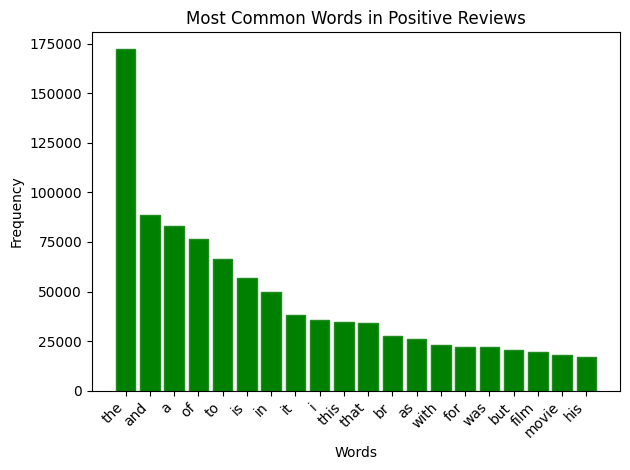

In [20]:
import string
from collections import Counter
import matplotlib.pyplot as plt

reviews = train_df[train_df["label"] == "positive"]["review"]

words = [
    word
    for review in reviews
    for word in review.lower().translate(
        str.maketrans("", "", string.punctuation)
    ).split()
]

word_counts = Counter(words)
top_20_words = word_counts.most_common(20)
words_list = [item[0] for item in top_20_words]
counts_list = [item[1] for item in top_20_words]

plt.bar(words_list, counts_list, color="green", edgecolor="forestgreen")

plt.title("Most Common Words in Positive Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

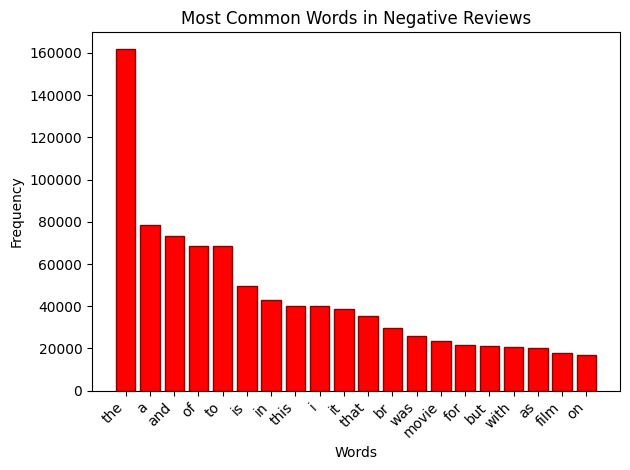

In [21]:
import string
from collections import Counter
import matplotlib.pyplot as plt

reviews = train_df[train_df["label"] == "negative"]["review"]

words = [
    word
    for review in reviews
    for word in review.lower().translate(
        str.maketrans("", "", string.punctuation)
    ).split()
]

word_counts = Counter(words)
top_20_words = word_counts.most_common(20)
words_list = [item[0] for item in top_20_words]
counts_list = [item[1] for item in top_20_words]

plt.bar(words_list, counts_list, color="red", edgecolor="darkred")

plt.title("Most Common Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Most Frequent Adjectives by Sentiment

**Part-of-Speech (POS) Tags**

Part-of-Speech (POS) tagging assigns a grammatical category to each word based on its role in a sentence.

| Tag | Abbreviation | Description | Example |
|---|---|---|---|
| `NN` | Noun | Singular noun | movie, story |
| `NNS` | Noun, plural | Plural noun | movies, actors |
| `VB` | Verb | Base form of a verb | like, watch |
| `VBD` | Verb, past tense | Past-tense verb | liked, watched |
| `VBG` | Verb, gerund/present participle | `-ing` form | watching, enjoying |
| `VBN` | Verb, past participle | Past participle | loved, finished |
| `VBP` | Verb, non-3rd person singular present | Present-tense verb | like, enjoy |
| `VBZ` | Verb, 3rd person singular present | Present-tense verb | likes, enjoys |
| `JJ` | Adjective | Describes a noun | good, amazing |
| `JJR` | Adjective, comparative | Comparative adjective | better, worse |
| `JJS` | Adjective, superlative | Superlative adjective | best, worst |
| `RB` | Adverb | Modifies a verb, adjective, or another adverb | very, quickly |
| `RBR` | Adverb, comparative | Comparative adverb | better, faster |
| `RBS` | Adverb, superlative | Superlative adverb | best, fastest |
| `DT` | Determiner | Specifies a noun | the, a, this |
| `PRP` | Personal pronoun | Personal pronoun | I, you, it |
| `IN` | Preposition/subordinating conjunction | Shows relationships between words | in, on, with |
| `CC` | Coordinating conjunction | Connects words or phrases | and, but, or |
| `CD` | Cardinal number | Number | one, two, 100 |
| `TO` | Infinitive marker | `to` before a verb | to watch |
| `MD` | Modal | Modal auxiliary verb | can, should, must |
| `.` | Punctuation | Sentence punctuation | `.`, `!`, `?` |

In [38]:
import nltk

# nltk.download("punkt")
# nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\putin\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [40]:
from nltk import pos_tag, word_tokenize

text = "This movie was absolutely amazing"

tokens = word_tokenize(text)
print(tokens)

tagged = pos_tag(tokens)

print(tagged)

['This', 'movie', 'was', 'absolutely', 'amazing']
[('This', 'DT'), ('movie', 'NN'), ('was', 'VBD'), ('absolutely', 'RB'), ('amazing', 'JJ')]


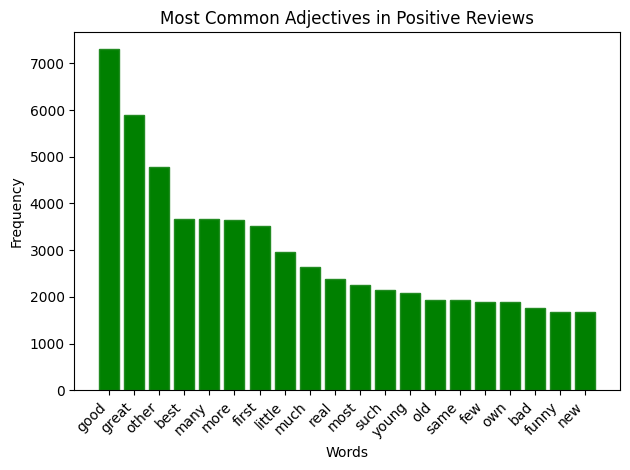

In [37]:
from nltk import pos_tag, word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

reviews = train_df[train_df["label"] == "positive"]["review"]

adj_words = []
for review in reviews:
    tokens = word_tokenize(review)
    tagged_words = pos_tag(tokens)
    for word, tag in tagged_words:
        if (
            tag in ("JJ", "JJR", "JJS")
            and word.isalpha()
            and word.lower() != "br"
        ):
            adj_words.append(word.lower())

word_counts = Counter(adj_words)
top_20_words = word_counts.most_common(20)
words_list = [item[0] for item in top_20_words]
counts_list = [item[1] for item in top_20_words]

plt.bar(words_list, counts_list, color="green", edgecolor="forestgreen")

plt.title("Most Common Adjectives in Positive Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

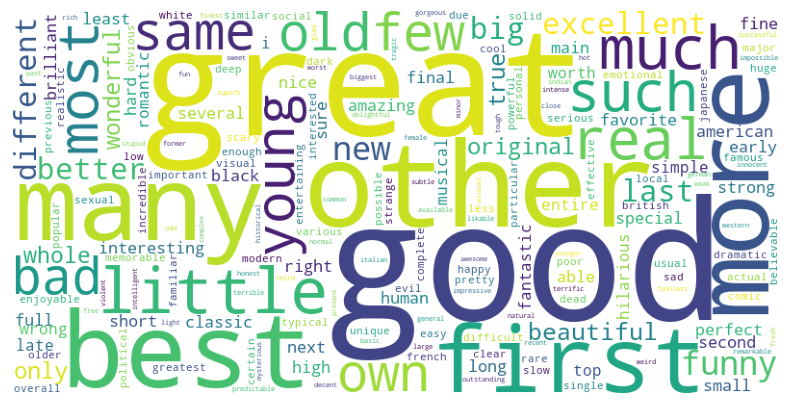

In [38]:
create_wordcloud(word_counts)

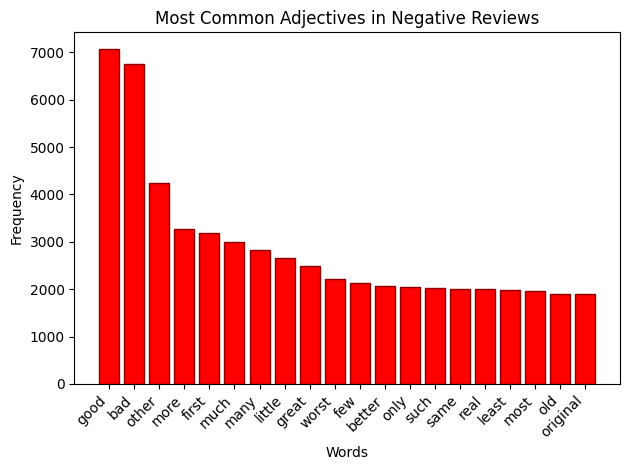

In [39]:
from nltk import pos_tag, word_tokenize
from collections import Counter
import matplotlib.pyplot as plt

reviews = train_df[train_df["label"] == "negative"]["review"]

adj_words = []
for review in reviews:
    tokens = word_tokenize(review)
    tagged_words = pos_tag(tokens)
    for word, tag in tagged_words:
        if (
            tag in ("JJ", "JJR", "JJS")
            and word.isalpha()
            and word.lower() != "br"
        ):
            adj_words.append(word.lower())

word_counts = Counter(adj_words)
top_20_words = word_counts.most_common(20)
words_list = [item[0] for item in top_20_words]
counts_list = [item[1] for item in top_20_words]

plt.bar(words_list, counts_list, color="red", edgecolor="darkred")

plt.title("Most Common Adjectives in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

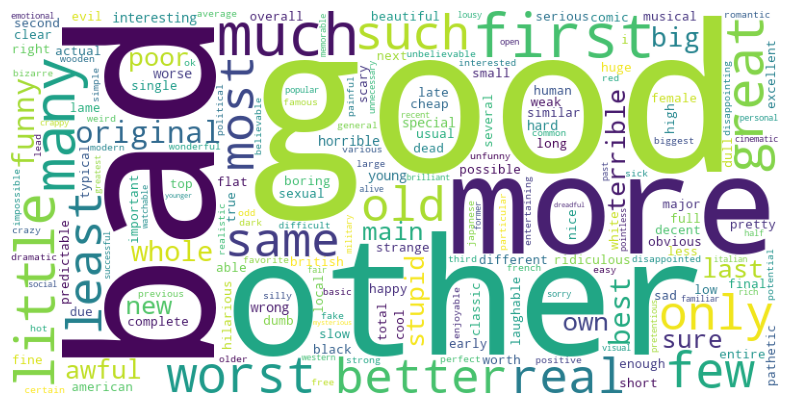

In [40]:
create_wordcloud(word_counts)

## Example of Positive and Negative Reviews

In [41]:
positive_reviews = train_df[train_df["label"] == "positive"]["review"]
negative_reviews = train_df[train_df["label"] == "negative"]["review"]

print("Positive Reviews:")
for review in positive_reviews.sample(3, random_state=42):
    print("-", review)

print("\nNegative Reviews:")
for review in negative_reviews.sample(3, random_state=42):
    print("-", review)

Positive Reviews:
- Loved it! What's not to like?--you got your suburbia, you got your zombies, you got your family issues, you got your social dilemmas, you got yourself one Fine Retro-1950's-style Flesh Eating Under Class Held At Bay By An Uneasy Worried About Whether They're The Next Meal Upper Crust. You couldn't ask for more.<br /><br />Cast is superb. Carrie Ann Moss is absolute perfection as a debutante social climbing housewife. She's both wanton, and criminally conspiratorial. Every fellow's dream. K'sun is really great as the son just trying to be as normal as possible in this nightmare existence, and somehow succeeding. He's a genuine screen presence. Very photogenic, and natural. Without naming them all, the rest of the cast is wonderful. Henry Czerny plays a suspicious policeman with honed instincts and little squeamishness as if it's his everyday persona. Billy Connolly is delightful as Fido. A fine actor: I wish that he had played the title role in "Braveheart," with Gib